In [1]:
# required setup and bug work-around for google colab
# fIrst time running: crashes and you have to click "Run all" again
# (https://github.com/googlecolab/colabtools/issues/5425)

# access package in repo
try:
  import woo_pong_py
except ImportError:
  !git clone https://github.com/tessmero/woo-pong-py.git
  !cp -r woo-pong-py/woo_pong_py/ .

# enable interactive figures
try:
  import ipympl
except ImportError:
  !pip install ipympl
  import os
  os.kill(os.getpid(), 9) # end session. user has to click 'Run all' again

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass # not running in google colab
    
%matplotlib widget

In [2]:


from woo_pong_py import DISK_DISK_LUT # pre-computed disk-disk collision lookup table
from woo_pong_py.sim import Simulation
from woo_pong_py.constants import DISK_RADIUS
from woo_pong_py.step import active_step

In [3]:
DISK_DISK_LUT.lut.shape

(21, 21, 41, 41, 4)

**Looping**

We iteratively solve a closed time-like loop, where a disk travels into the past and interacts with itself. We create a simulation with one disk, and add a 'spawn event' partway through. At the spawn event, a disk spawns from the time-travel portal at the top of the view. 

We start by manually creating a spawn event. We pick a time and trajectory such that it collides with the original disk, sending it into the time-travel portal at the bottom of the view.

In [4]:

from woo_pong_py.util import sim_pyplot_animation, DISK_RADIUS, VALUE_SCALE

sim = Simulation(DISK_DISK_LUT,seed=1234,n_disks=1)

# enter portal at bottom of view, travel back in time, exit portal at top of view
# the portal may offset x-coordinate but maintains velocity

# params to optimize
start_dx = 100
start_dy = 0
spawn_on_step = 1000
spawn_dx = 0
spawn_dy = 100

# turn off gravity
sim.gravity_x = 0
sim.gravity_y = 0

# set original disk to move from left to right
original_disk = sim.disks[0]
original_disk.current_state.x = DISK_RADIUS
original_disk.current_state.y = 50 * VALUE_SCALE # midpoint on left wall
original_disk.next_state.dx = start_dx
original_disk.next_state.dy = start_dy

# add spawn event
sim.is_loop = True
sim.spawn_on_step = spawn_on_step
sim.spawn_x = 50 * VALUE_SCALE
sim.spawn_y = DISK_RADIUS
sim.spawn_dx = spawn_dx
sim.spawn_dy = spawn_dy

# run sim see if loop connects
for i in range(10000):
    active_step(sim)

    if sim.step_count > 5000 and not sim.has_collided:
        print(f"spawned disk did not collide with original")
        break

    if sim.entered_portal_on_step != -1:
        state = sim.disks[0].current_state
        svel = f"{state.dx},{state.dy}"
        expected = f"{sim.spawn_dx},{sim.spawn_dy}"
        print(f"entered bottom portal on step {sim.entered_portal_on_step} with velocity {svel}. expected velocity: {expected}")
        break

    


entered bottom portal on step 7500 with velocity 145,145. expected velocity: 0,100


**Optimize Loop Parameters**

Now we use scipy.optimize.leastsq to find the optimal parameters that create a perfect closed time loop. The objective function measures how closely the disk's velocity when entering the portal matches the expected spawn velocity.

In [5]:
from scipy.optimize import least_squares, minimize
import numpy as np

def run_loop_sim(params):
    """
    Run simulation with given parameters and return the velocity error.
    
    Parameters to optimize:
    - params[0]: start_dx (initial velocity x)
    - params[1]: start_dy (initial velocity y)
    - params[2]: spawn_on_step (when the spawned disk appears)
    - params[3]: spawn_dx (spawned disk velocity x)
    - params[4]: spawn_dy (spawned disk velocity y)
    
    Returns: [dx_error, dy_error] - difference between actual and expected velocity
    """
    start_dx, start_dy, spawn_on_step, spawn_dx, spawn_dy = params
    
    # Convert to integers
    start_dx = int(start_dx)
    start_dy = int(start_dy)
    spawn_on_step = int(spawn_on_step)
    spawn_dx = int(spawn_dx)
    spawn_dy = int(spawn_dy)
    
    # Create simulation
    sim = Simulation(DISK_DISK_LUT, seed=1234, n_disks=1)
    
    # Turn off gravity
    sim.gravity_x = 0
    sim.gravity_y = 0
    
    # Set original disk to start position
    original_disk = sim.disks[0]
    original_disk.current_state.x = DISK_RADIUS
    original_disk.current_state.y = 50 * VALUE_SCALE
    original_disk.next_state.dx = start_dx
    original_disk.next_state.dy = start_dy
    
    # Add spawn event
    sim.is_loop = True
    sim.spawn_on_step = spawn_on_step
    sim.spawn_x = 50 * VALUE_SCALE
    sim.spawn_y = DISK_RADIUS
    sim.spawn_dx = spawn_dx
    sim.spawn_dy = spawn_dy
    
    # Run simulation
    for i in range(10000):
        active_step(sim)
        
        # Check if spawned disk failed to collide
        if sim.step_count > 5000 and not sim.has_collided:
            # Large penalty for no collision
            return [10000, 10000]
        
        # Check if disk entered portal
        if sim.entered_portal_on_step != -1:
            state = sim.disks[0].current_state
            # Calculate error between actual and expected velocity
            dx_error = state.dx - spawn_dx
            dy_error = state.dy - spawn_dy
            return [dx_error, dy_error]
    
    # If we get here, loop didn't complete
    return [10000, 10000]

# Initial guess (from your manual attempt)
initial_params = [100, 0, 1000, 0, 100]
    
print(f"Initial params: start_dx={initial_params[0]}, start_dy={initial_params[1]}, " 
      f"spawn_on_step={initial_params[2]}, spawn_dx={initial_params[3]}, spawn_dy={initial_params[4]}")
print(f"Initial error: {run_loop_sim(initial_params)}")
print()

# Define objective as sum of squared errors for minimize
eval_count = [0]
def objective(params):
    errors = run_loop_sim(params)
    cost = errors[0]**2 + errors[1]**2
    eval_count[0] += 1
    if eval_count[0] % 10 == 0:
        print(f"  Eval {eval_count[0]}: cost={cost:.0f}, params=[{int(params[0])}, {int(params[1])}, {int(params[2])}, {int(params[3])}, {int(params[4])}], error={errors}")
    return cost

# Run multiple optimization rounds with progressively tighter tolerances
from scipy.optimize import minimize, differential_evolution

current_params = initial_params
n_rounds = 10  # Reduced rounds since we stop at error magnitude < 5

for round_num in range(1, n_rounds + 1):
    print(f"\n{'='*60}")
    print(f"OPTIMIZATION ROUND {round_num}/{n_rounds}")
    print(f"{'='*60}")
    
    # Check current error
    current_error = run_loop_sim(current_params)
    current_cost = current_error[0]**2 + current_error[1]**2
    
    print(f"Starting this round with: params=[{int(current_params[0])}, {int(current_params[1])}, {int(current_params[2])}, {int(current_params[3])}, {int(current_params[4])}]")
    print(f"Current error: {current_error}, cost: {current_cost}")
    
    # Stop if we've reached zero error or error is small enough
    if current_cost == 0:
        print(f"\n✓✓✓ ZERO ERROR ACHIEVED! ✓✓✓")
        break
    elif current_cost < 25:  # Error magnitude < 5 (since cost = dx^2 + dy^2)
        print(f"\n✓ Error is small enough (magnitude < 5), stopping optimization!")
        break
    
    # Use different strategies based on how stuck we are
    if current_cost < 200 and round_num > 3:
        # When close but stuck, use differential evolution for global search
        print("Using Differential Evolution for better global search...")
        bounds = [
            (current_params[0] - 20, current_params[0] + 20),  # start_dx
            (current_params[1] - 20, current_params[1] + 20),  # start_dy
            (current_params[2] - 50, current_params[2] + 50),  # spawn_on_step
            (current_params[3] - 20, current_params[3] + 20),  # spawn_dx
            (current_params[4] - 20, current_params[4] + 20),  # spawn_dy
        ]
        
        eval_count[0] = 0
        result = differential_evolution(
            objective, bounds,
            strategy='best1bin',
            maxiter=50,
            popsize=10,
            tol=0.01,
            atol=0,
            disp=True
        )
    else:
        # Standard Nelder-Mead with adaptive settings
        if current_cost < 5:  # Almost zero
            max_iters = 60
            max_fev = 600
            xatol = 0.01
            fatol = 0.01
            initial_simplex_scale = 0.5
        elif current_cost < 25:  # Very very close
            max_iters = 50
            max_fev = 500
            xatol = 0.05
            fatol = 0.05
            initial_simplex_scale = 1.0
        elif current_cost < 100:  # Very close
            max_iters = 60
            max_fev = 600
            xatol = 0.1
            fatol = 0.1
            initial_simplex_scale = 2.0
        elif current_cost < 500:  # Close
            max_iters = 80
            max_fev = 800
            xatol = 0.3
            fatol = 0.3
            initial_simplex_scale = 3.0
        else:  # Far or moderate
            max_iters = 100
            max_fev = 1000
            xatol = 1.0
            fatol = 1.0
            initial_simplex_scale = 5.0
        
        print(f"Settings: maxiter={max_iters}, maxfev={max_fev}, xatol={xatol}, fatol={fatol}, simplex_scale={initial_simplex_scale}")
        print()
        
        # Create initial simplex with larger exploration
        initial_simplex = [current_params]
        for i in range(5):
            perturbed = current_params.copy()
            perturbed[0] += np.random.uniform(-initial_simplex_scale, initial_simplex_scale)
            perturbed[1] += np.random.uniform(-initial_simplex_scale, initial_simplex_scale)
            perturbed[2] += np.random.uniform(-initial_simplex_scale*2, initial_simplex_scale*2)
            perturbed[3] += np.random.uniform(-initial_simplex_scale, initial_simplex_scale)
            perturbed[4] += np.random.uniform(-initial_simplex_scale, initial_simplex_scale)
            initial_simplex.append(perturbed)
        
        eval_count[0] = 0
        result = minimize(objective, current_params, method='Nelder-Mead', 
                          options={'disp': True, 'maxiter': max_iters, 'maxfev': max_fev, 
                                   'xatol': xatol, 'fatol': fatol,
                                   'initial_simplex': initial_simplex})
    
    # Update current params for next round
    current_params = result.x
    
    final_error = run_loop_sim(result.x)
    print(f"\nRound {round_num} complete!")
    print(f"  Optimized params: [{int(result.x[0])}, {int(result.x[1])}, {int(result.x[2])}, {int(result.x[3])}, {int(result.x[4])}]")
    print(f"  Final velocity error: {final_error}")
    print(f"  Function evaluations this round: {result.nfev}")

print(f"\n{'='*60}")
print(f"ALL OPTIMIZATION ROUNDS COMPLETE!")
print(f"{'='*60}")

# final optimized parameters
opt_start_dx, opt_start_dy, opt_spawn_on_step, opt_spawn_dx, opt_spawn_dy = [int(p) for p in current_params]
final_error = run_loop_sim(current_params)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Initial params: start_dx=100, start_dy=0, spawn_on_step=1000, spawn_dx=0, spawn_dy=100
Initial error: [145, 45]


OPTIMIZATION ROUND 1/10
Starting this round with: params=[100, 0, 1000, 0, 100]
Current error: [145, 45], cost: 23050
Settings: maxiter=100, maxfev=1000, xatol=1.0, fatol=1.0, simplex_scale=5.0

  Eval 10: cost=200000000, params=[98, -1, 997, 0, 98], error=[10000, 10000]
  Eval 20: cost=27521, params=[99, 0, 1002, 0, 99], error=[136, 95]
  Eval 30: cost=200000000, params=[99, 0, 1001, 0, 99], error=[10000, 10000]
  Eval 40: cost=27521, params=[99, 0, 1002, 0, 99], error=[136, 95]
  Eval 50: cost=27521, params=[99, 0, 1002, 0, 99], error=[136, 95]
  Eval 60: cost=13154, params=[99, 0, 1002, 0, 100], error=[85, 77]
Optimization terminated successfully.
         Current function value: 13154.000000
         Iterations: 19
         Function evaluations: 60

Round 1 complete!
  Optimized params: [99, 0, 1002, 0, 100]
  Final velocity error: [85, 77]
  Function evaluations this r

In [8]:
# Quick summary of final result
print("="*60)
print("FINAL OPTIMIZATION SUMMARY")
print("="*60)
print(f"Optimized Parameters:")
print(f"  start_dx={opt_start_dx}, start_dy={opt_start_dy}")
print(f"  spawn_on_step={opt_spawn_on_step}")
print(f"  spawn_dx={opt_spawn_dx}, spawn_dy={opt_spawn_dy}")
print(f"\nVelocity Error: {final_error}")
print(f"Error Magnitude: {(final_error[0]**2 + final_error[1]**2)**0.5:.1f}")
print("="*60)

FINAL OPTIMIZATION SUMMARY
Optimized Parameters:
  start_dx=93, start_dy=-7
  spawn_on_step=1038
  spawn_dx=-9, spawn_dy=109

Velocity Error: [-1, 0]
Error Magnitude: 1.0


**Visualize Optimized Loop**

Now we can visualize the optimized closed time loop where the disk trajectory perfectly connects through the portal.

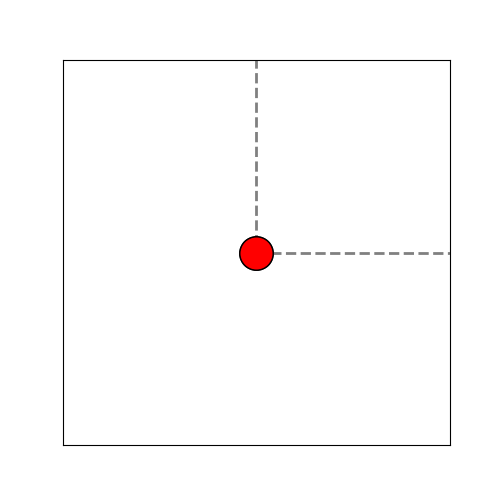

In [9]:
# Create simulation with optimized parameters
def buildSim():
    sim = Simulation(DISK_DISK_LUT, seed=1234, n_disks=1)

    # Turn off gravity
    sim.gravity_x = 0
    sim.gravity_y = 0

    # Set original disk with optimized initial velocity
    original_disk = sim.disks[0]
    original_disk.current_state.x = DISK_RADIUS
    original_disk.current_state.y = 50 * VALUE_SCALE
    original_disk.next_state.dx = opt_start_dx
    original_disk.next_state.dy = opt_start_dy

    # Add spawn event with optimized parameters
    sim.is_loop = True
    sim.spawn_on_step = opt_spawn_on_step
    sim.spawn_x = 50 * VALUE_SCALE
    sim.spawn_y = DISK_RADIUS
    sim.spawn_dx = opt_spawn_dx
    sim.spawn_dy = opt_spawn_dy

    return sim


from woo_pong_py.util import sim_loop_pyplot_animation

# Animate the optimized loop
ani_optimized = sim_loop_pyplot_animation(
    buildSim(),buildSim(), # loop animation requires two copies of the sim
    steps_per_frame=100,
)
ani_optimized